In [1]:
import pandas as pd

# Load the new CSV file for the 2023 temperature data

outdoor_temp_df = pd.read_csv('./campaign_data/outdoor_temp.csv')

# Convert 'Date/Time' to datetime format and extract the date
outdoor_temp_df['Date/Time'] = pd.to_datetime(outdoor_temp_df['Date/Time'])

outdoor_temp_df['Date'] = outdoor_temp_df['Date/Time'].dt.date

# Group the data by date and 'site_id' to find the daily max and min temperatures for each sensor
daily_max_min_per_sensor = outdoor_temp_df.groupby(['Date', 'sensor_id_outdoor_temp'])['Value'].agg(['max', 'min']).reset_index()

# Now, average these daily maximums and minimums across all sensors to obtain single max and min values for each day
average_daily_max_min = daily_max_min_per_sensor.groupby('Date').agg({'max': 'mean', 'min': 'mean'}).reset_index()

average_daily_max_min['Date']  = pd.to_datetime(average_daily_max_min['Date'])
average_daily_max_min.sort_values(by=['Date'],inplace=True)

# Prepare the data for plotting
min_dates_campaign = average_daily_max_min['Date']
max_dates_campaign = average_daily_max_min['Date']
min_temps_campaign = average_daily_max_min['min']
max_temps_campaign = average_daily_max_min['max']

# min_dates_campaign = average_daily_max_min['Date']


/tmp/ipykernel_46464/3748993504.py:5: DtypeWarning: Columns (7,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  outdoor_temp_df = pd.read_csv('./campaign_data/outdoor_temp.csv')


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pandas.plotting import register_matplotlib_converters

# Load the data
min_temp_df = pd.read_csv('GMET_data/minimum_temperatures_transformed_sorted.csv')
max_temp_df = pd.read_csv('GMET_data/maximum_temperatures_transformed_sorted.csv')

# Convert the 'DATE' column to datetime
min_temp_df['DATE'] = pd.to_datetime(min_temp_df['DATE'])
max_temp_df['DATE'] = pd.to_datetime(max_temp_df['DATE'])

# Filter the data to include only dates up to the end of 2021
min_temp_until_2021_df = min_temp_df[min_temp_df['DATE'].dt.year <= 2021]
max_temp_until_2021_df = max_temp_df[max_temp_df['DATE'].dt.year <= 2021]

# Extract the data for the year 2022
min_temp_2022_df = min_temp_df[min_temp_df['DATE'].dt.year >= 2022]
max_temp_2022_df = max_temp_df[max_temp_df['DATE'].dt.year >= 2022]

# Calculate the daily statistics
min_temp_stats = min_temp_until_2021_df.groupby(min_temp_until_2021_df['DATE'].dt.dayofyear)['TEMPERATURE'].describe(percentiles=[.10, .25, .75, .90])
max_temp_stats = max_temp_until_2021_df.groupby(max_temp_until_2021_df['DATE'].dt.dayofyear)['TEMPERATURE'].describe(percentiles=[.10, .25, .75, .90])

# Apply a 7-day rolling window to smooth the statistics
min_temp_smoothed = min_temp_stats.rolling(window=7, min_periods=1, center=True).mean()
max_temp_smoothed = max_temp_stats.rolling(window=7, min_periods=1, center=True).mean()

# Function to convert the day of the year back to the actual date in 2022
def dayofyear_to_date(dayofyear, year=2022):
    return pd.to_datetime(year*1000 + dayofyear, format='%Y%j')

# Prepare the data for plotting
min_dates_2022 = min_temp_2022_df['DATE']
max_dates_2022 = max_temp_2022_df['DATE']
min_temps_2022 = min_temp_2022_df['TEMPERATURE']
max_temps_2022 = max_temp_2022_df['TEMPERATURE']

# Convert 'Date/Time' to datetime format and extract the date
# min_dates_campaign  = pd.to_datetime(min_dates_campaign)
# Find the overlapping dates between GMET 2022 data and campaign data
overlapping_dates = set(min_dates_2022).intersection(set(min_dates_campaign))

# Ensure you're working with copies to avoid SettingWithCopyWarning
gmet_min_2022_overlap = min_temp_2022_df[min_temp_2022_df['DATE'].isin(overlapping_dates)].copy()
gmet_max_2022_overlap = max_temp_2022_df[max_temp_2022_df['DATE'].isin(overlapping_dates)].copy()

# Now perform the operations
# gmet_min_2022_overlap['DATE'] = gmet_min_2022_overlap['DATE'].apply(lambda x: x.replace(year=2022))
# gmet_max_2022_overlap['DATE'] = gmet_max_2022_overlap['DATE'].apply(lambda x: x.replace(year=2022))

campaign_overlap = average_daily_max_min[average_daily_max_min['Date'].isin(overlapping_dates)].copy()

# campaign_overlap['Date'] = campaign_overlap['Date'].apply(lambda x: x.replace(year=2022))


In [ ]:
campaign_overlap.Date

In [ ]:
# Create the plot
plt.figure(figsize=(15, 7))

# Plot the smoothed percentile bands for minimum temperatures
plt.fill_between(dayofyear_to_date(min_temp_smoothed.index),
                 min_temp_smoothed['10%'],
                 min_temp_smoothed['90%'],
                 color='blue', alpha=0.1)

plt.fill_between(dayofyear_to_date(min_temp_smoothed.index),
                 min_temp_smoothed['25%'],
                 min_temp_smoothed['75%'],
                 color='blue', alpha=0.2)

# Plot the smoothed percentile bands for maximum temperatures
plt.fill_between(dayofyear_to_date(max_temp_smoothed.index),
                 max_temp_smoothed['10%'],
                 max_temp_smoothed['90%'],
                 color='red', alpha=0.1)

plt.fill_between(dayofyear_to_date(max_temp_smoothed.index),
                 max_temp_smoothed['25%'],
                 max_temp_smoothed['75%'],
                 color='red', alpha=0.2)

# Plot the smoothed average high and low temperatures
plt.plot(dayofyear_to_date(min_temp_smoothed.index), min_temp_smoothed['mean'], color='blue', alpha=0.5)
plt.plot(dayofyear_to_date(max_temp_smoothed.index), max_temp_smoothed['mean'], color='red', alpha=0.5)

# Plot the individual daily temperature ranges for 2022 as grey lines
# for i in range(len(min_dates_2022)):
#     plt.plot([min_dates_2022.iloc[i], max_dates_2022.iloc[i]], 
#              [min_temps_2022.iloc[i], max_temps_2022.iloc[i]], 
#              color='grey', alpha=0.5)

# Plot the individual daily temperature ranges from the campaign as green lines
# for i in range(len(min_dates_campaign)):
#     plt.plot([min_dates_campaign.iloc[i], max_dates_campaign.iloc[i]], 
#              [min_temps_campaign.iloc[i], max_temps_campaign.iloc[i]], 
#              color='green', alpha=0.25)

# # Plot the individual daily temperature ranges for 2022 as grey lines (only overlapping dates)
for i in range(len(gmet_min_2022_overlap)):
    plt.plot([gmet_min_2022_overlap['DATE'].iloc[i], gmet_min_2022_overlap['DATE'].iloc[i]], 
             [gmet_min_2022_overlap['TEMPERATURE'].iloc[i], gmet_max_2022_overlap['TEMPERATURE'].iloc[i]], 
             color='purple', alpha=0.5)

# # # Plot the individual daily temperature ranges for the campaign data as green lines (only overlapping dates)
for i in range(len(campaign_overlap)):
    plt.plot([campaign_overlap['Date'].iloc[i], campaign_overlap['Date'].iloc[i]], 
             [campaign_overlap['min'].iloc[i], campaign_overlap['max'].iloc[i]], 
             color='green', alpha=0.5)

# Improve the aesthetics of the plot
plt.title('Daily Temperature Ranges with Smoothed Percentile Bands')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)

# Format the x-axis to show months
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.gca().xaxis.set_minor_locator(mdates.DayLocator())

# Show the plot
plt.savefig('temp_range_comparisons_GMET_campaign.png')


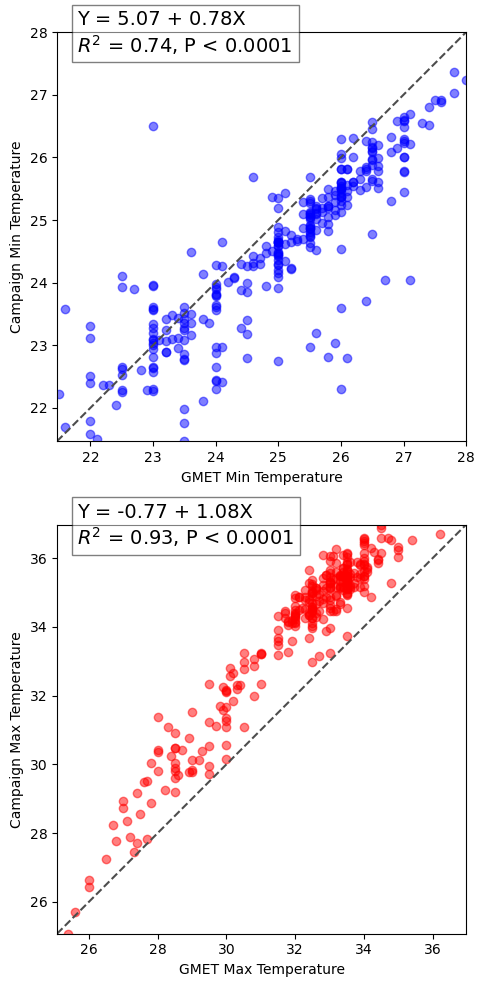

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pandas.plotting import register_matplotlib_converters

register_matplotlib_converters()

# # Function to annotate the regression fit
# def annotate_fit(x, y, ax):
#     if not x.empty and not y.empty:
#         df = pd.DataFrame({'x': x, 'y': y}).dropna()
#         if not df.empty:
#             print('zboop')
#             X = sm.add_constant(df['x'])
#             model = sm.OLS(df['y'], X).fit()
#             a, b = model.params['const'], model.params['x']
#             r2 = model.rsquared
#             p_value_slope = model.pvalues['x']
#             if p_value_slope < 0.0001:
#                 p_text = "P < 0.0001"
#             else:
#                 p_text = f"P = {p_value_slope:.4f}"
#             ax.annotate(f'Y = {a:.2f} + {b:.2f}X\n$R^2$ = {r2:.2f}, {p_text}', xy=(0.05, 0.875), xycoords='axes fraction', fontsize=14)

def annotate_fit(x, y, ax):
    # Reset the indices of both Series to ensure alignment
    x_reset = x.reset_index(drop=True)
    y_reset = y.reset_index(drop=True)

    # Now, create the DataFrame with reset indices
    df = pd.DataFrame({'x': x_reset, 'y': y_reset}).dropna()

    if not df.empty:
        X = sm.add_constant(df['x'])
        model = sm.OLS(df['y'], X).fit()
        a, b = model.params['const'], model.params['x']
        r2 = model.rsquared
        p_value_slope = model.pvalues['x']

        if p_value_slope < 0.0001:
            p_text = "P < 0.0001"
        else:
            p_text = f"P = {p_value_slope:.4f}"

        # Adjust annotation position if needed to ensure visibility
        ax.annotate(f'Y = {a:.2f} + {b:.2f}X\n$R^2$ = {r2:.2f}, {p_text}', 
                    xy=(0.05, 0.95), xycoords='axes fraction', 
                    fontsize=14, bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))
    else:
        print("DataFrame created from x and y is empty.")


# Function to find common limits for the axes
def find_common_limits(x, y):
    combined = pd.concat([x, y])
    return (combined.min(), combined.max())

# Assuming your GMET data and campaign data are already loaded and preprocessed as shown previously

# Find overlapping dates
overlapping_dates = set(min_temp_2022_df['DATE']).intersection(set(campaign_overlap['Date']))

# Check if there are overlapping dates
if not overlapping_dates:
    raise ValueError("There are no overlapping dates between GMET and campaign data.")

# Filter to only overlapping dates
min_temp_2022_overlap = min_temp_2022_df[min_temp_2022_df['DATE'].isin(overlapping_dates)]
max_temp_2022_overlap = max_temp_2022_df[max_temp_2022_df['DATE'].isin(overlapping_dates)]
campaign_overlap = campaign_overlap[campaign_overlap['Date'].isin(overlapping_dates)]

# Check if the overlap DataFrames are not empty
if min_temp_2022_overlap.empty or campaign_overlap.empty:
    raise ValueError("The filtered overlap data is empty. Cannot perform correlation analysis.")

# Correlation analysis
# Min temperatures
plt.figure(figsize=(10, 10))
ax_min = plt.subplot(211)
if not min_temp_2022_overlap.empty and not campaign_overlap['min'].empty:
    min_limits = find_common_limits(min_temp_2022_overlap['TEMPERATURE'], campaign_overlap['min'])
    ax_min.set_xlim(min_limits)
    ax_min.set_ylim(min_limits)
    ax_min.set_aspect('equal')
    ax_min.plot(min_limits, min_limits, ls="--", c=".3")
    ax_min.scatter(min_temp_2022_overlap['TEMPERATURE'], campaign_overlap['min'], c='blue', alpha=0.5)
    annotate_fit(min_temp_2022_overlap['TEMPERATURE'], campaign_overlap['min'], ax_min)
ax_min.set_xlabel('GMET Min Temperature')
ax_min.set_ylabel('Campaign Min Temperature')

# Max temperatures
ax_max = plt.subplot(212)
if not max_temp_2022_overlap.empty and not campaign_overlap['max'].empty:
    max_limits = find_common_limits(max_temp_2022_overlap['TEMPERATURE'], campaign_overlap['max'])
    ax_max.set_xlim(max_limits)
    ax_max.set_ylim(max_limits)
    ax_max.set_aspect('equal')
    ax_max.plot(max_limits, max_limits, ls="--", c=".3")
    ax_max.scatter(max_temp_2022_overlap['TEMPERATURE'], campaign_overlap['max'], c='red', alpha=0.5)
    annotate_fit(max_temp_2022_overlap['TEMPERATURE'], campaign_overlap['max'], ax_max)
ax_max.set_xlabel('GMET Max Temperature')
ax_max.set_ylabel('Campaign Max Temperature')

plt.tight_layout()
plt.savefig('GMET_campaign_min_max_comparisons.png', bbox_inches='tight')


/tmp/ipykernel_46464/896553654.py:7: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  campaign_humidity_df = pd.read_csv('./campaign_data/outdoor_hum.csv')


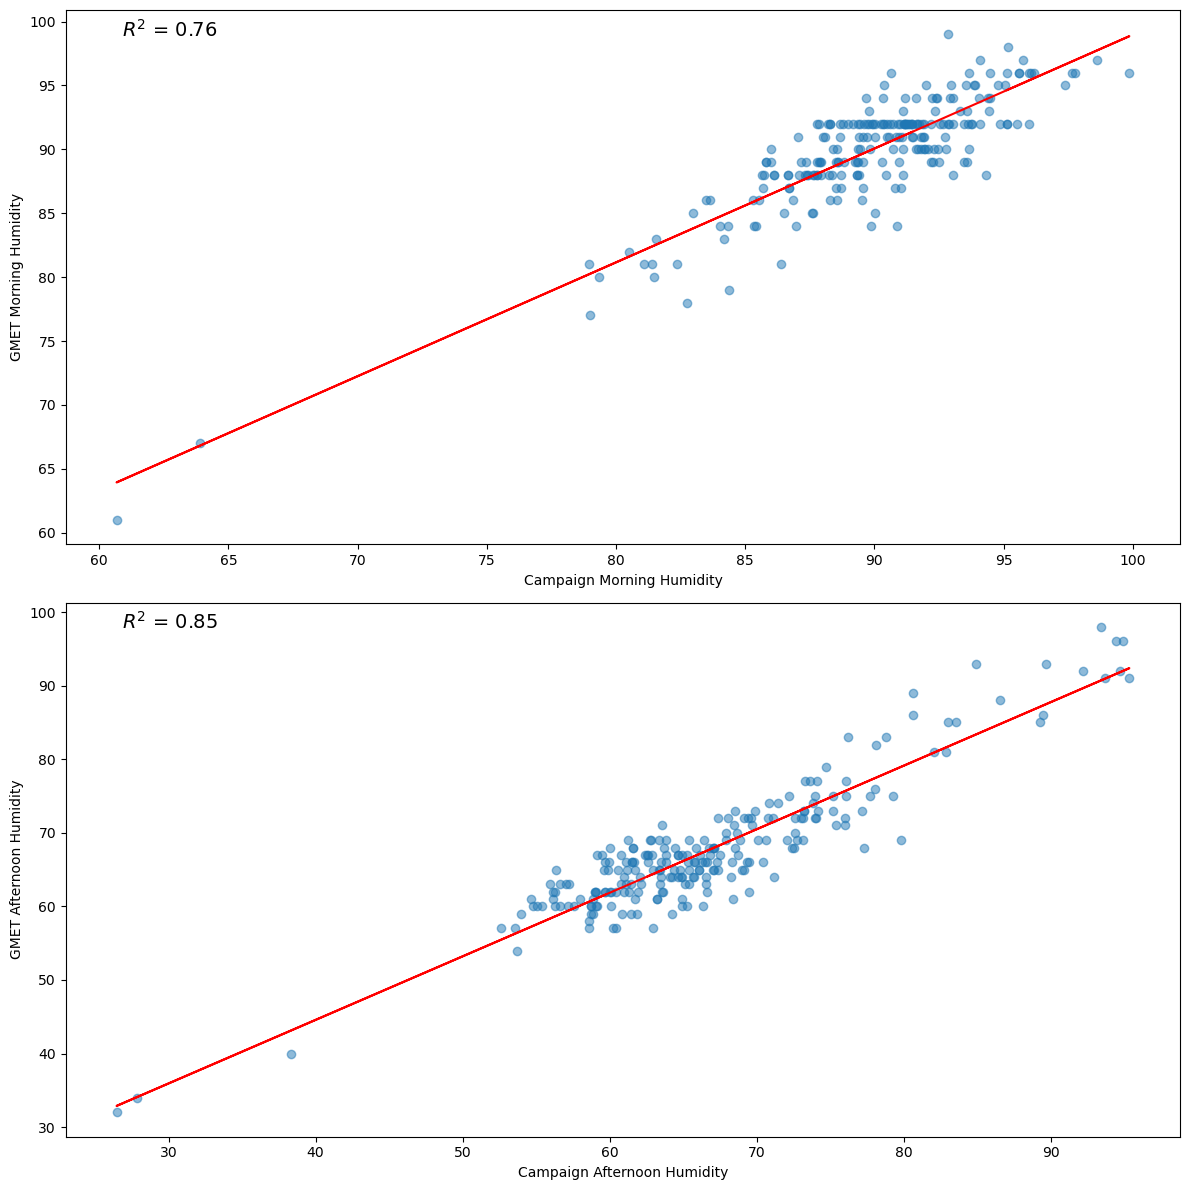

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Load the GMET and campaign humidity data
gmet_humidity_df = pd.read_csv('GMET_data/relative_humidity_transformed_sorted.csv')
campaign_humidity_df = pd.read_csv('./campaign_data/outdoor_hum.csv')

# Convert the datetime information into pandas datetime format
gmet_humidity_df['DATETIME'] = pd.to_datetime(gmet_humidity_df['DATETIME'])
campaign_humidity_df['Date/Time'] = pd.to_datetime(campaign_humidity_df['Date/Time'])

# For the campaign data, calculate the average humidity across all sensors for the timestamps closest to 06:00 and 15:00 each day
campaign_humidity_df['Hour'] = campaign_humidity_df['Date/Time'].dt.hour
morning = campaign_humidity_df[(campaign_humidity_df['Hour'] == 6)]
afternoon = campaign_humidity_df[(campaign_humidity_df['Hour'] == 15)]

# Take the average for each sensor closest to 06:00 and 15:00
campaign_humidity_morning_avg = morning.groupby(morning['Date/Time'].dt.date).agg({'Value':'mean'}).reset_index()
campaign_humidity_afternoon_avg = afternoon.groupby(afternoon['Date/Time'].dt.date).agg({'Value':'mean'}).reset_index()

# GMET humidity data is already at 06:00 and 15:00, so just extract the date and the value
gmet_humidity_df['Date'] = gmet_humidity_df['DATETIME'].dt.date
gmet_humidity_morning = gmet_humidity_df[gmet_humidity_df['DATETIME'].dt.hour == 6]
gmet_humidity_afternoon = gmet_humidity_df[gmet_humidity_df['DATETIME'].dt.hour == 15]

# Merge the GMET data with campaign averages based on the date
merged_morning = pd.merge(gmet_humidity_morning, campaign_humidity_morning_avg, left_on='Date', right_on='Date/Time', how='inner')
merged_afternoon = pd.merge(gmet_humidity_afternoon, campaign_humidity_afternoon_avg, left_on='Date', right_on='Date/Time', how='inner')

# Function to perform linear regression and plot
def plot_regression(x, y, ax, xlabel, ylabel):
    ax.scatter(x, y, alpha=0.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    ax.plot(x, model.predict(X), color='red')
    r2 = model.rsquared
    ax.annotate(f'$R^2$ = {r2:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=14)

# Create the plot for the morning and afternoon comparisons
fig, ax = plt.subplots(2, 1, figsize=(12, 12))

plot_regression(merged_morning['Value'], merged_morning['HUMIDITY'], ax[0], 'Campaign Morning Humidity', 'GMET Morning Humidity')
plot_regression(merged_afternoon['Value'], merged_afternoon['HUMIDITY'], ax[1], 'Campaign Afternoon Humidity', 'GMET Afternoon Humidity')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pandas.plotting import register_matplotlib_converters

register_matplotlib_converters()

# Load the humidity datasets
gmet_humidity_df = pd.read_csv('GMET_data/relative_humidity_transformed_sorted.csv')
campaign_humidity_df = pd.read_csv('2023_11_20/outdoor_hum_meta_tagged.csv')

# Convert the datetime information into pandas datetime format
gmet_humidity_df['DATETIME'] = pd.to_datetime(gmet_humidity_df['DATETIME'])
campaign_humidity_df['Date/Time'] = pd.to_datetime(campaign_humidity_df['Date/Time'])

# Round campaign times to the nearest hour for calculation of averages closest to 06:00 and 15:00
campaign_humidity_df['RoundedTime'] = campaign_humidity_df['Date/Time'].dt.round('H')

# Filter out only the times of interest (06:00 and 15:00)
campaign_humidity_df_6 = campaign_humidity_df[campaign_humidity_df['RoundedTime'].dt.hour == 6]
campaign_humidity_df_15 = campaign_humidity_df[campaign_humidity_df['RoundedTime'].dt.hour == 15]

# Average out the humidity readings across different sites for each timestamp
campaign_humidity_6_avg = campaign_humidity_df_6.groupby(campaign_humidity_df_6['RoundedTime'].dt.date)['Value'].mean().reset_index(name='avg_humidity_6')
campaign_humidity_15_avg = campaign_humidity_df_15.groupby(campaign_humidity_df_15['RoundedTime'].dt.date)['Value'].mean().reset_index(name='avg_humidity_15')

# Merge the GMET data with the campaign averages based on the date
gmet_humidity_df['Date'] = gmet_humidity_df['DATETIME'].dt.date
merged_humidity_6 = pd.merge(gmet_humidity_df[gmet_humidity_df['DATETIME'].dt.hour == 6], campaign_humidity_6_avg, left_on='Date', right_on='RoundedTime')
merged_humidity_15 = pd.merge(gmet_humidity_df[gmet_humidity_df['DATETIME'].dt.hour == 15], campaign_humidity_15_avg, left_on='Date', right_on='RoundedTime')

# Function to perform linear regression and plot
def plot_regression(x, y, xlabel, ylabel, title, color):
    plt.scatter(x, y, alpha=0.5, color=color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    plt.plot(x, model.predict(X), color='red')
    annotate_fit(x, y, plt.gca())

# Create the plot for the morning comparison
plt.figure(figsize=(10, 5))
plot_regression(merged_humidity_6['avg_humidity_6'], merged_humidity_6['HUMIDITY'], 'Campaign Average Humidity at 06:00', 'GMET Humidity at 06:00', 'GMET vs Campaign Humidity Comparison at 06:00', 'blue')
plt.savefig('humidity_comparison_6.png', bbox_inches='tight')
plt.show()

# Create the plot for the afternoon comparison
plt.figure(figsize=(10, 5))
plot_regression(merged_humidity_15['avg_humidity_15'], merged_humidity_15['HUMIDITY'], 'Campaign Average Humidity at 15:00', 'GMET Humidity at 15:00', 'GMET vs Campaign Humidity Comparison at 15:00', 'green')
plt.savefig('humidity_comparison_15.png', bbox_inches='tight')
plt.show()
